In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
df = pd.read_csv('../data/churn-bigml-20.csv')
df.head()


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


In [80]:
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000
mean,102.841079,436.157421,8.407796,180.948126,100.937031,30.761769,203.355322,100.476762,17.285262,199.685307,100.113943,8.985907,10.238381,4.527736,2.764948,1.563718
std,40.819480,41.783305,13.994480,55.508628,20.396790,9.436463,49.719268,18.948262,4.226160,49.759931,20.172505,2.239429,2.807850,2.482442,0.758167,1.333357
min,1.000000,408.000000,0.000000,25.900000,30.000000,4.400000,48.100000,37.000000,4.090000,23.200000,42.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,76.000000,408.000000,0.000000,146.250000,87.500000,24.860000,171.050000,88.000000,14.540000,167.950000,86.000000,7.560000,8.600000,3.000000,2.320000,1.000000
50%,102.000000,415.000000,0.000000,178.300000,101.000000,30.310000,203.700000,101.000000,17.310000,201.600000,100.000000,9.070000,10.500000,4.000000,2.840000,1.000000
75%,128.000000,415.000000,20.000000,220.700000,115.000000,37.520000,236.450000,113.000000,20.095000,231.500000,113.500000,10.420000,12.050000,6.000000,3.255000,2.000000
max,232.000000,510.000000,51.000000,334.300000,165.000000,56.830000,361.800000,168.000000,30.750000,367.700000,175.000000,16.550000,18.300000,18.000000,4.940000,8.000000


In [81]:
df.isnull().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [82]:
df[df.duplicated()]
df.drop_duplicates(keep='first', subset=None, inplace=True)

In [83]:
df.rename(columns=str.lower, inplace=True)
df.columns = df.columns.str.replace(' ', '_')

In [84]:
df['state'] = df['state'].str.strip().str.lower()

In [85]:
df.head(5)

,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,la,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,in,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,ny,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,sc,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,hi,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


In [86]:
df['international_plan'] = df['international_plan'].astype('bool')
df['state'] = df['state'].astype('category')
df['voice_mail_plan'] = df['voice_mail_plan'].astype('bool')
df['area_code'] = df['area_code'].astype('category')


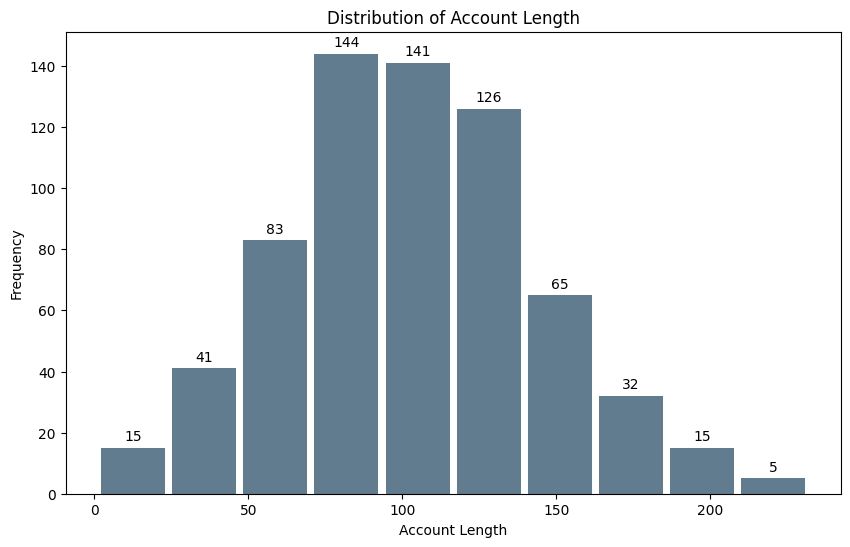

In [87]:
fig,ax = plt.subplots(figsize=(10,6))
avg, bins, patches = ax.hist(df['account_length'], bins=10, rwidth=0.9, color='#607c8e')
ax.bar_label(patches, fmt='%.0f', padding=3) 
plt.title('Distribution of Account Length')
plt.xlabel('Account Length')
plt.ylabel('Frequency')
plt.show()

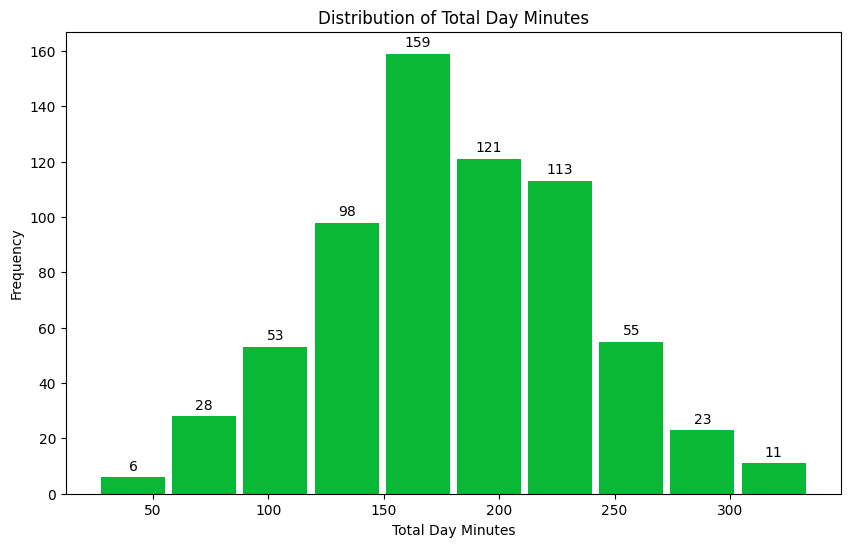

In [88]:
fig, ax = plt.subplots(figsize=(10,6))
n, bins, patches = ax.hist(df['total_day_minutes'], bins=10, rwidth=0.9, color="#09b835")
ax.bar_label(patches, fmt='%.0f', padding=3)
plt.title('Distribution of Total Day Minutes')              
plt.xlabel('Total Day Minutes')
plt.ylabel('Frequency')     
plt.show()

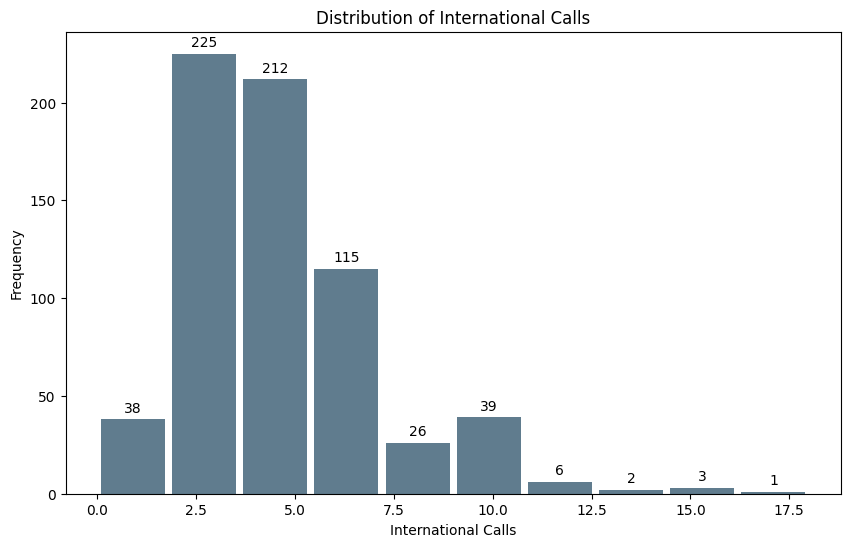

In [89]:
fig, ax = plt.subplots(figsize=(10,6))
n, bins, patches = ax.hist(df['total_intl_calls'], bins=10, rwidth=0.9, color='#607c8e')
ax.bar_label(patches, fmt='%.0f', padding=3)
plt.title('Distribution of International Calls')        
plt.xlabel('International Calls')
plt.ylabel('Frequency')     
plt.show()

In [94]:
df['account_length'].describe()

count    667.000000
mean     102.841079
std       40.819480
min        1.000000
25%       76.000000
50%      102.000000
75%      128.000000
max      232.000000
Name: account_length, dtype: float64

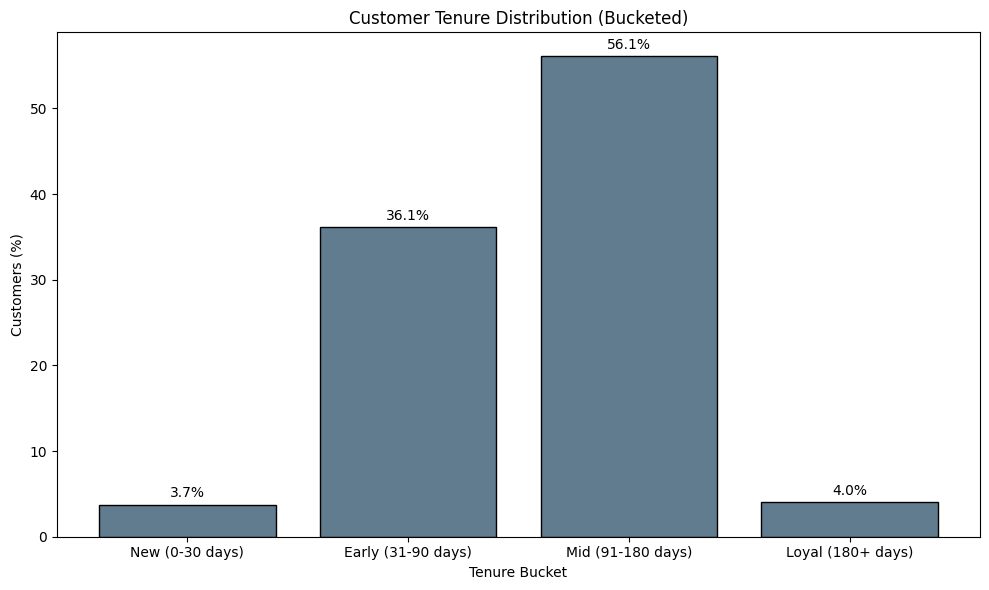

In [ ]:
import numpy as np
bins = [0, 30, 90, 180 , np.inf]
labels = ['New (0-30 days)', 'Early (31-90 days)', 'Mid (91-180 days)', 'Loyal (180+ days)']
df['tenure_bucket'] = pd.cut(df['account_length'], bins=bins, labels=labels, include_lowest=True, right=True)
bucket_counts = df['tenure_bucket'].value_counts().reindex(labels)
bucket_pct = (bucket_counts / len(df)) * 100 
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(bucket_pct.index.astype(str), bucket_pct.values, color='#607c8e', edgecolor='black')

ax.set_title('Customer Tenure Distribution')
ax.set_xlabel('Tenure Bucket')
ax.set_ylabel('Customers (%)')

ax.bar_label(bars, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

